In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
file = '/content/drive/MyDrive/The Museum of Edible Earth/The Museum of Edible Earth/clean_dirt_final.csv'
df = pd.read_csv(file)
df.head()

,index,Name,Country,Composition,Shape,Color,Acq Date,OG_Date,Acq Method,Edibility,Tags,Taste,Texture,Acq Year,Acq Month
0,0,SatinAr Clay,Armenia,Clay,Powder,Brown,2021-09-19,2021-09-19,Present,Eaten,NaN,NaN,NaN,2021.0,September
1,1,SatinAr Clay,Armenia,Clay,Powder,Brown,2023-08-01,NaN,Private seller,Eaten,NaN,NaN,NaN,2023.0,NaN
2,2,Schindele's Mineralen,Austria,Clay,Powder,Brown,2022-02-02,2022-02-02,Present,Eaten,"calcium, chemical, creamy, fine, iron, mineral...","Metallic, Chemical, Milky, Earthy, Experience,...","Chalky, Creamy, Powdery, Hard, Dry, Experience...",2022.0,February
3,3,Basic Detox Plus,Austria,Other,Powder,Grey,2022-05-31,2022-05-31,Shop,Eaten,NaN,NaN,NaN,2022.0,May
4,4,taste your soil: ars electronica,Austria,Sand,Powder,Brown,2021-09-12,2021-09-12,Project,Not Eaten,NaN,NaN,NaN,2021.0,September


In [ ]:
df['Acq Year'] = df['Acq Year'].astype('Int64')
counts = df['Acq Year'].value_counts().reset_index()
counts = counts.sort_values(by = 'count', ascending = False)
counts

,Acq Year,count
0,2017,147
1,2019,121
2,2021,113
3,2020,109
4,2016,47
5,2022,46
6,2024,26
7,2018,12
8,2013,10
9,2015,10


In [ ]:
countsm = df['Acq Month'].value_counts().reset_index()
countsm = countsm.sort_values(by = 'count', ascending = False)
countsm

,Acq Month,count
0,June,151
1,July,53
2,October,46
3,May,43
4,November,36
5,September,32
6,April,32
7,August,30
8,January,29
9,December,23


(array([2008., 2010., 2012., 2014., 2016., 2018., 2020., 2022., 2024.,
        2026.]),
 [Text(2008.0, 0, '2008'),
  Text(2010.0, 0, '2010'),
  Text(2012.0, 0, '2012'),
  Text(2014.0, 0, '2014'),
  Text(2016.0, 0, '2016'),
  Text(2018.0, 0, '2018'),
  Text(2020.0, 0, '2020'),
  Text(2022.0, 0, '2022'),
  Text(2024.0, 0, '2024'),
  Text(2026.0, 0, '2026')])

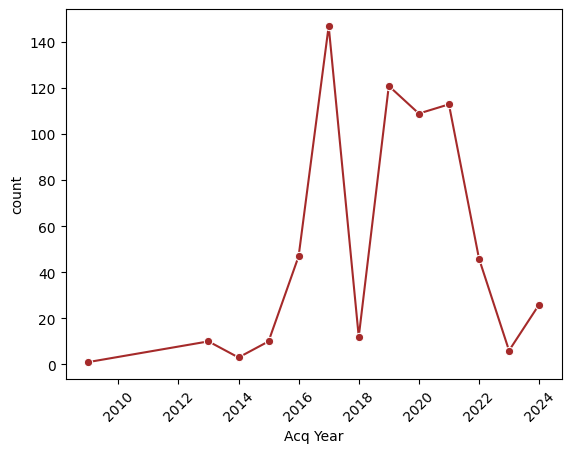

In [ ]:
sns.lineplot(data = counts, x = 'Acq Year', y = 'count', marker = 'o', color = 'brown')
plt.xticks(rotation = 45)

In [ ]:
top = df['Country'].value_counts().reset_index().nlargest(10, 'count')
top10 = df[df['Country'].isin(top['Country'])]
top10 = top10.groupby(['Acq Year', 'Country']).size().reset_index(name = 'Count')
t10 = df[df['Country'].isin(top['Country'])]

<ipython-input-7-06c425cdbb9e>:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1), loc='upper left')


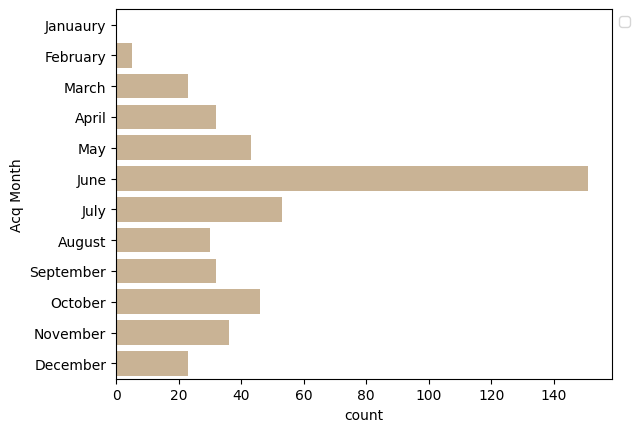

In [ ]:
ticks = ['Januaury', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data = df, y = 'Acq Month', order = ticks, color = 'tan')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

**Observations:**

- The samples in the dataset have been collected from 2009 to 2024.
- The highest years for collection were 2017, 19, 20 and 21.
- 2018 was a surprisingly steep drop off in sample collection.
- The lowest years for sample collection were 2009, 2013, 2014, 2015 and 2023.
- The highest number of samples collected in 1 year was 147 in 2017.
- The highest number of samples collected in 1 year in 1 country was 38 in Suriname (Surprisingly not Russia).
- So for some reason, an absolutely overwhelming number of samples are collected in the month of June. A majority of these come from the top years as well.
- There is a 3 year sample collection gap between 2009 and 2013 near the beginning of the exhibits life cycle. What's up with *that*?

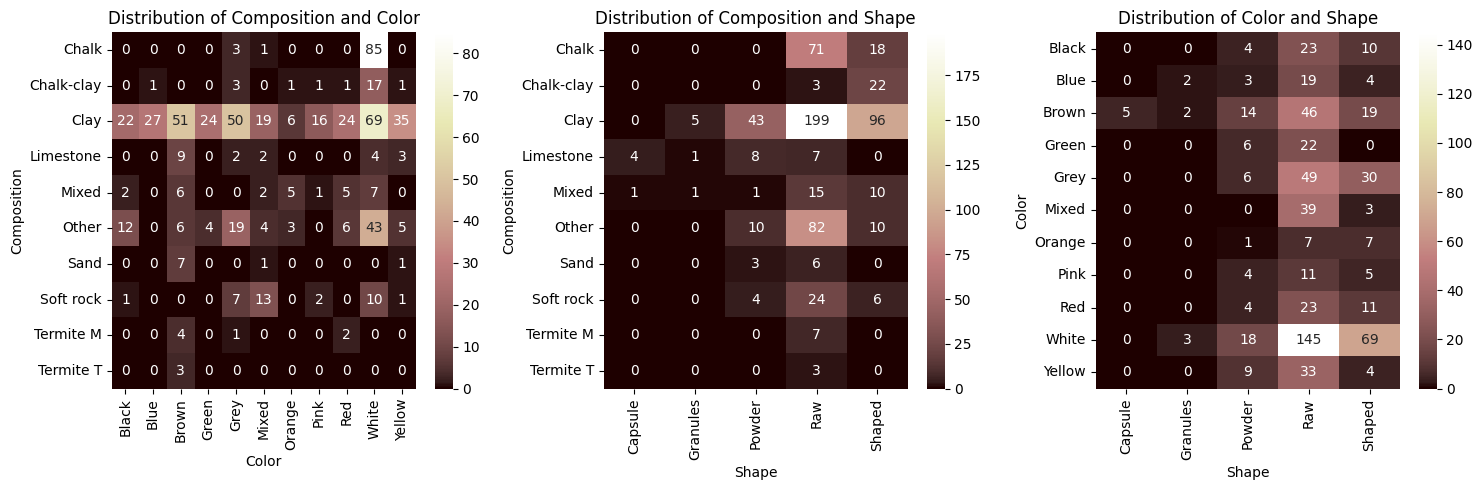

In [ ]:
cross = pd.crosstab(df['Composition'], df['Color'])
cross2 = pd.crosstab(df['Composition'], df['Shape'])
cross3 = pd.crosstab(df['Color'], df['Shape'])

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize=(15, 5))

ax[0] = sns.heatmap(data = cross, annot = True, fmt = 'd', cmap = 'pink', ax = ax[0])
ax[0].set_title('Distribution of Composition and Color')
ax[0].set_xlabel('Color')
ax[0].set_ylabel('Composition')

ax[1] = sns.heatmap(data = cross2, annot = True, fmt = 'd', cmap = 'pink', ax = ax[1])
ax[1].set_title('Distribution of Composition and Shape')
ax[1].set_xlabel('Shape')
ax[1].set_ylabel('Composition')

ax[2] = sns.heatmap(data = cross3, annot = True, fmt = 'd', cmap = 'pink', ax = ax[2])
ax[2].set_title('Distribution of Color and Shape')
ax[2].set_xlabel('Shape')
ax[2].set_ylabel('Color')

plt.tight_layout()

plt.show()

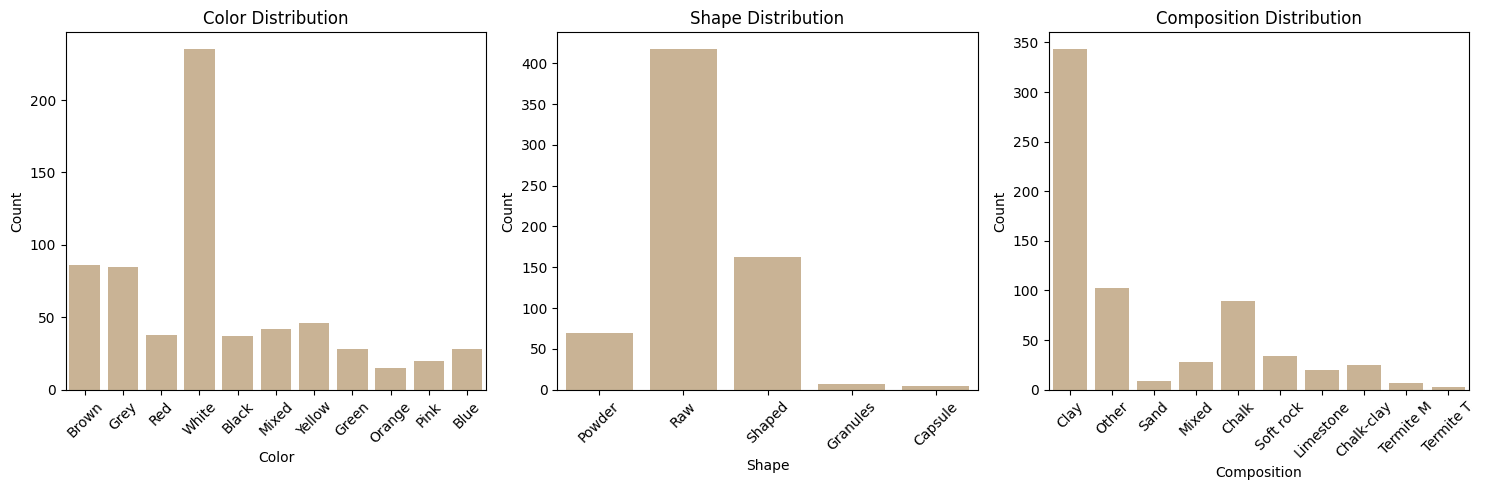

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize=(15, 5))

ax[0] = sns.countplot(data = df, x = 'Color', color = 'tan', ax = ax[0])
ax[0].set_title('Color Distribution')
ax[0].set_xlabel('Color')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', labelrotation=45)

ax[1] = sns.countplot(data = df, x ='Shape', color = 'tan', ax = ax[1])
ax[1].set_title('Shape Distribution')
ax[1].set_xlabel('Shape')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis='x', labelrotation=45)

ax[2] = sns.countplot(data = df, x = 'Composition', color = 'tan', ax = ax[2])
ax[2].set_title('Composition Distribution')
ax[2].set_xlabel('Composition')
ax[2].set_ylabel('Count')
ax[2].tick_params(axis='x', labelrotation=45)

plt.tight_layout()

plt.show()

**Insights:**

The most common color is white, Shape is raw and Composition is clay, and it's not even close. Most of the distributions are completely overrun by these attributes.

The most common combinations of shape and color are: [Raw + White], [Shaped + White], [Raw + Grey] and [Raw + Brown].

The most common combinations of composition and shape are: [Raw + Clay], [Shaped + Clay], [Raw + Other] and [Raw + Chalk].

The most common combinations of composition and color are: [Chalk + White], [Clay + White], [Clay + Brown], [Clay + Grey] and [Clay + Other]. It's interesting how even though clay is the most common composition, the number of [Chalk + White] minerals are more present than any of the clay combinations.

Generally, the most common combinations align with the most common attributes except for the [Chalk + White] items mentioned above.

Now, let's take a look at the different acquisition channels (Acq Method) and see how they compare/correlate with the other items.

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Present'),
  Text(1, 0, 'Private seller'),
  Text(2, 0, 'Shop'),
  Text(3, 0, 'Project'),
  Text(4, 0, 'Internet'),
  Text(5, 0, 'Market'),
  Text(6, 0, 'Other'),
  Text(7, 0, 'Field research'),
  Text(8, 0, 'Exchange')])

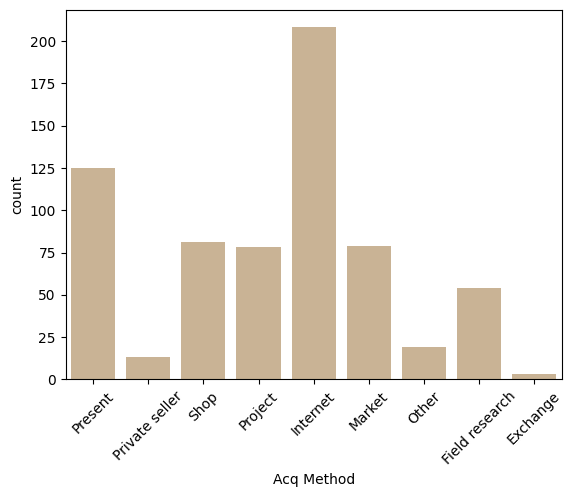

In [ ]:
sns.countplot(x = 'Acq Method', color = 'tan', data = df)
plt.xticks(rotation = 45)

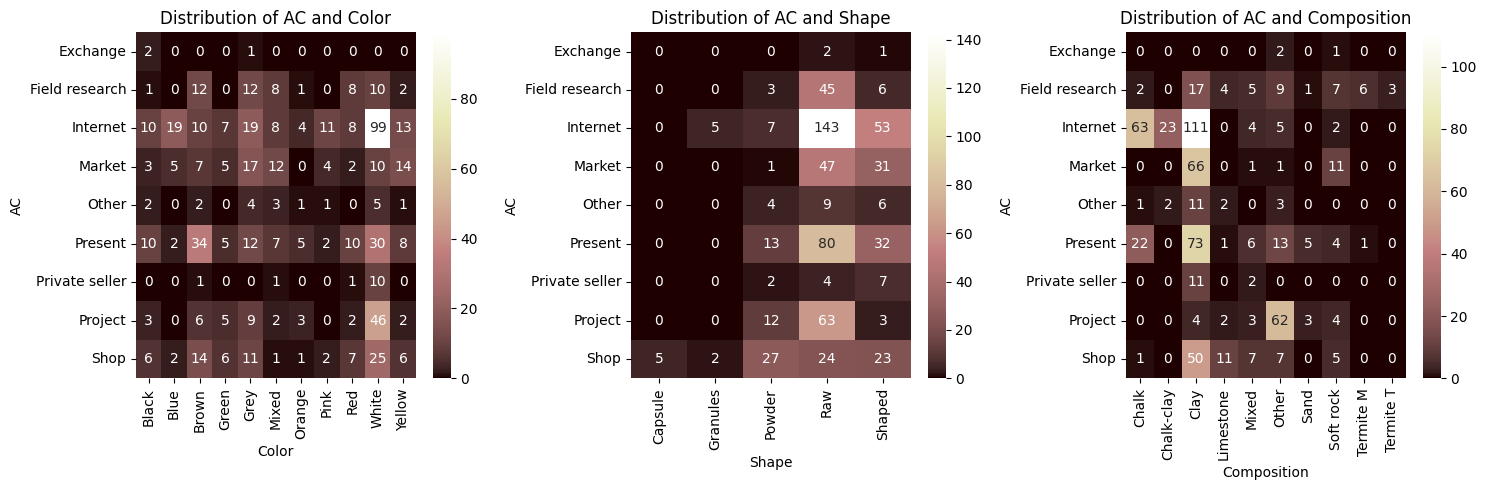

In [ ]:
cross4 = pd.crosstab(df['Acq Method'], df['Color'])
cross5 = pd.crosstab(df['Acq Method'], df['Shape'])
cross6 = pd.crosstab(df['Acq Method'], df['Composition'])

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize=(15, 5))

ax[0] = sns.heatmap(data = cross4, annot = True, fmt = 'd', cmap = 'pink', ax = ax[0])
ax[0].set_title('Distribution of AC and Color')
ax[0].set_xlabel('Color')
ax[0].set_ylabel('AC')

ax[1] = sns.heatmap(data = cross5, annot = True, fmt = 'd', cmap = 'pink', ax = ax[1])
ax[1].set_title('Distribution of AC and Shape')
ax[1].set_xlabel('Shape')
ax[1].set_ylabel('AC')

ax[2] = sns.heatmap(data = cross6, annot = True, fmt = 'd', cmap = 'pink', ax = ax[2])
ax[2].set_title('Distribution of AC and Composition')
ax[2].set_xlabel('Composition')
ax[2].set_ylabel('AC')

plt.tight_layout()

plt.show()

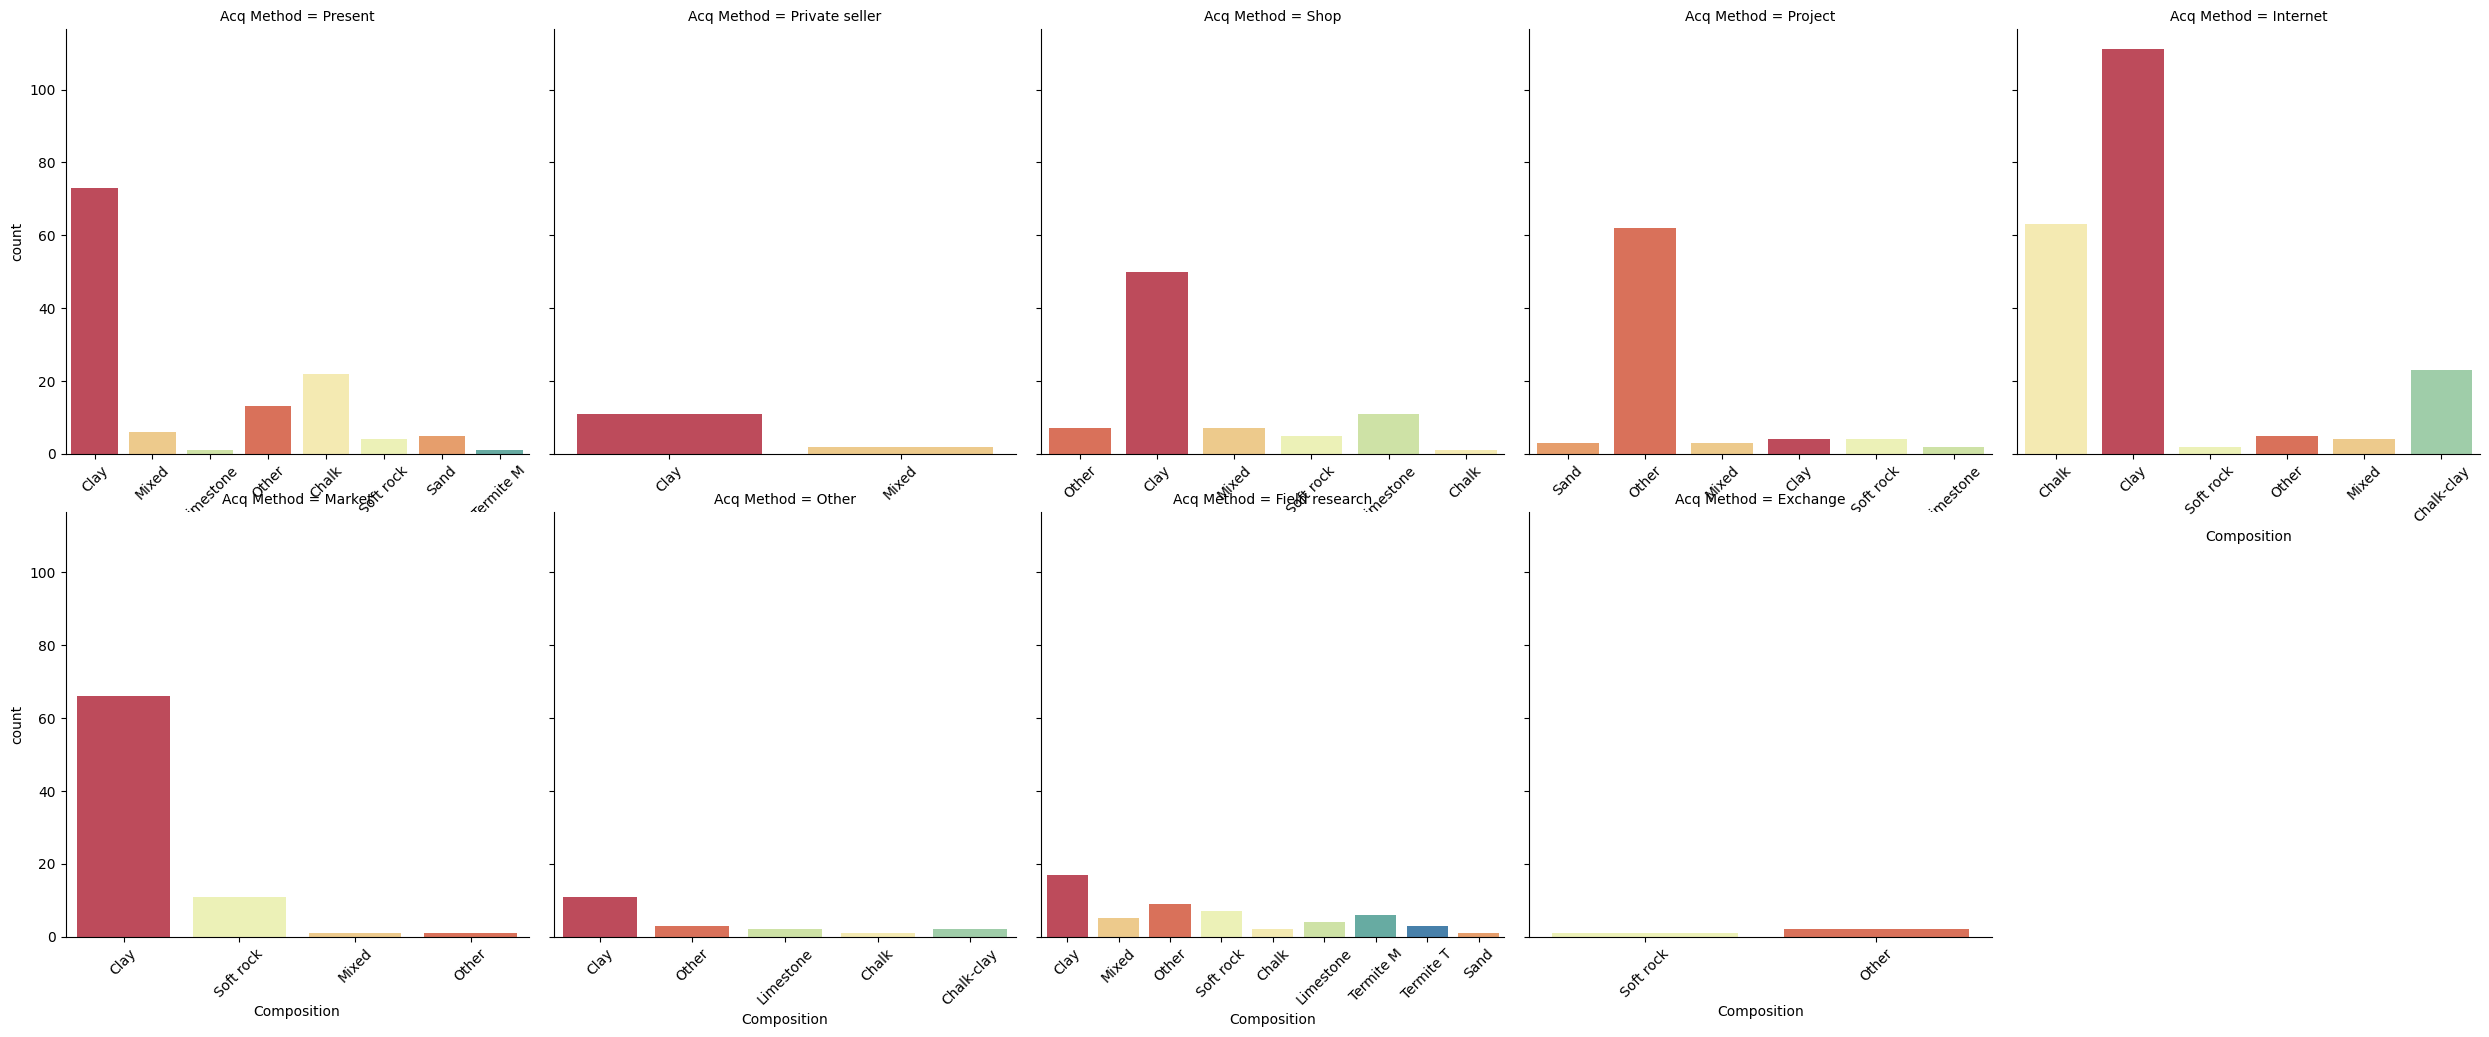

In [ ]:
ax = sns.catplot(x = 'Composition', data = df, col = 'Acq Method', kind = "count", col_wrap = 5, palette = 'Spectral', hue = 'Composition', sharex = False)
plt.tight_layout()
ax.tick_params(axis='x', labelrotation=45)

**Insights:**

The top 2 channels for sample collection are by internet and by present.

**Anomalies:**

All of the termite-based samples come from field research. Field research also has the highest variety of minerals.

A large number of compositions described as 'other' were collected by project channels.

Chalk and chalk-clay compositions were mostly from internet channels.

(Everything else is in line with the overall composition distribution and channel distribution.)

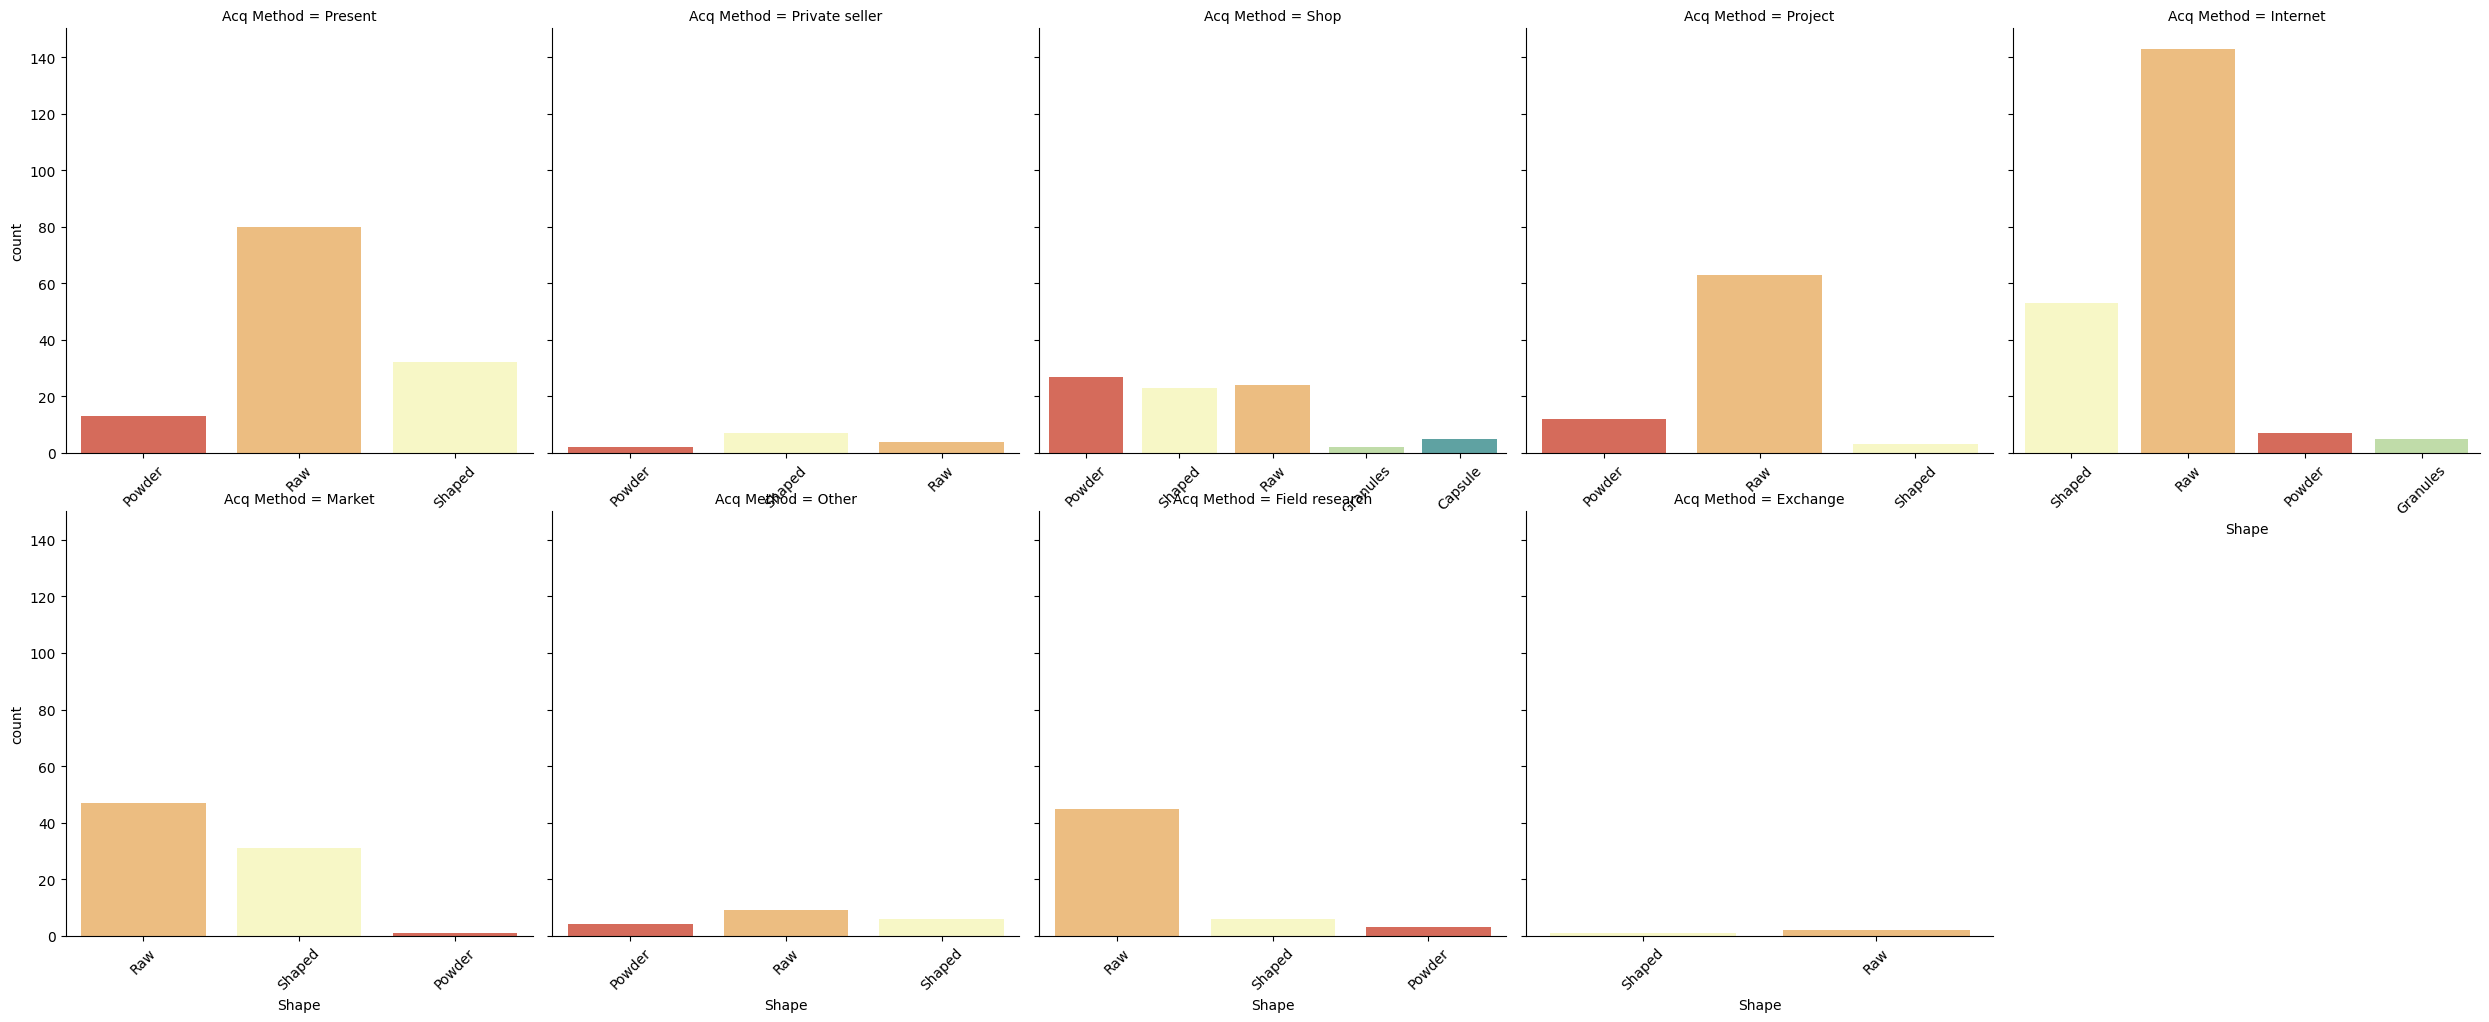

In [ ]:
ax = sns.catplot(x = 'Shape', data = df, col = 'Acq Method', kind = "count", col_wrap = 5, palette = 'Spectral', hue = 'Shape', sharex = False)
ax.tick_params(axis = 'x', labelrotation = 45)

Capsule shaped samples only come from shop channels.

(Everything else is in line with the overall shape distribution and channel distribution.)

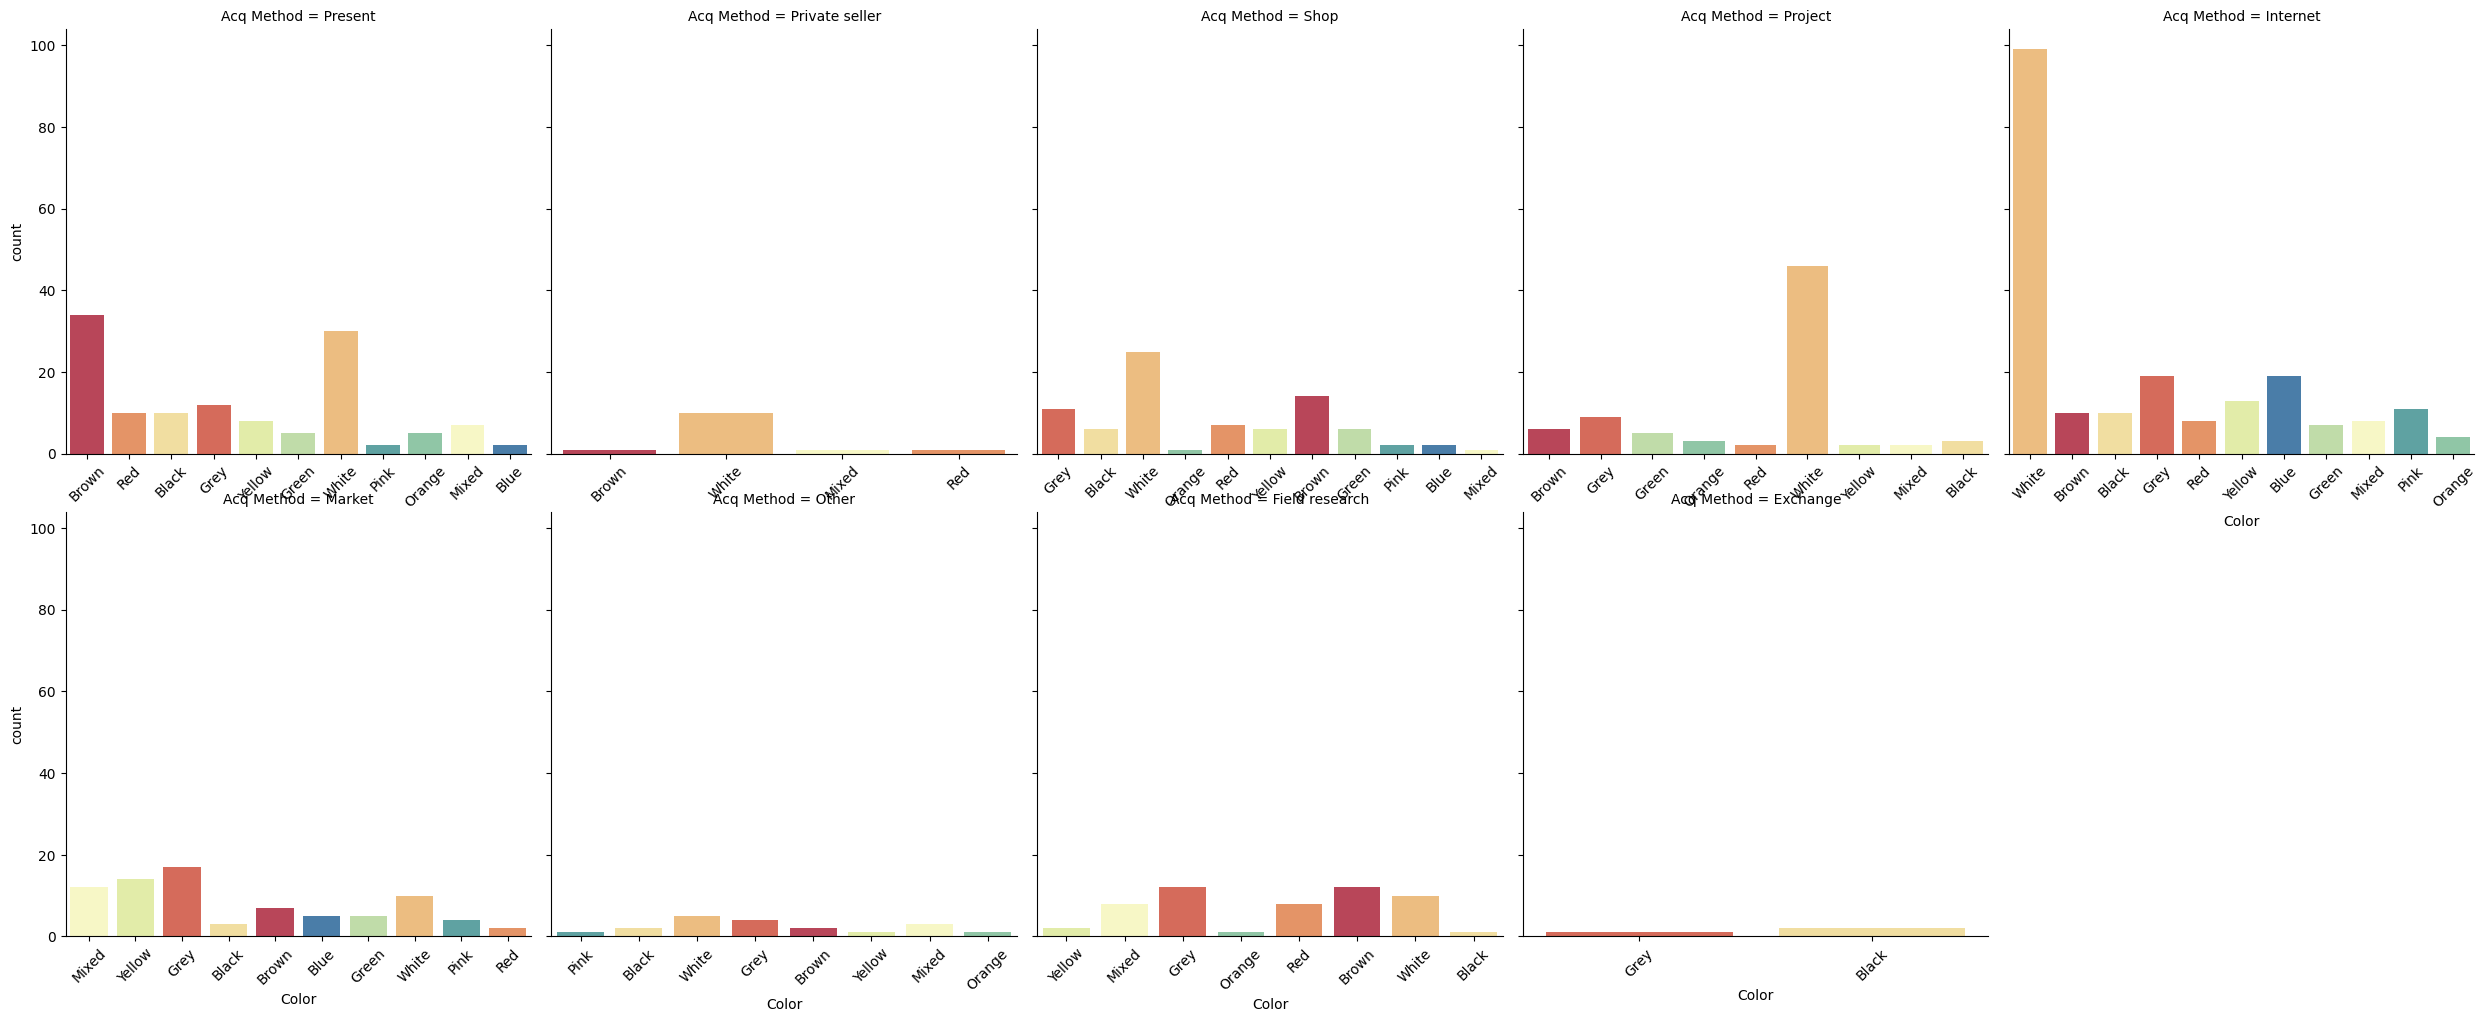

In [ ]:
ax = sns.catplot(x = 'Color', data = df, col = 'Acq Method', kind = "count", col_wrap = 5, palette = 'Spectral', hue = 'Color', sharex=False)
ax.tick_params(axis='x', labelrotation=45)

Everything here is in line with the overall color distribution and channel distribution.

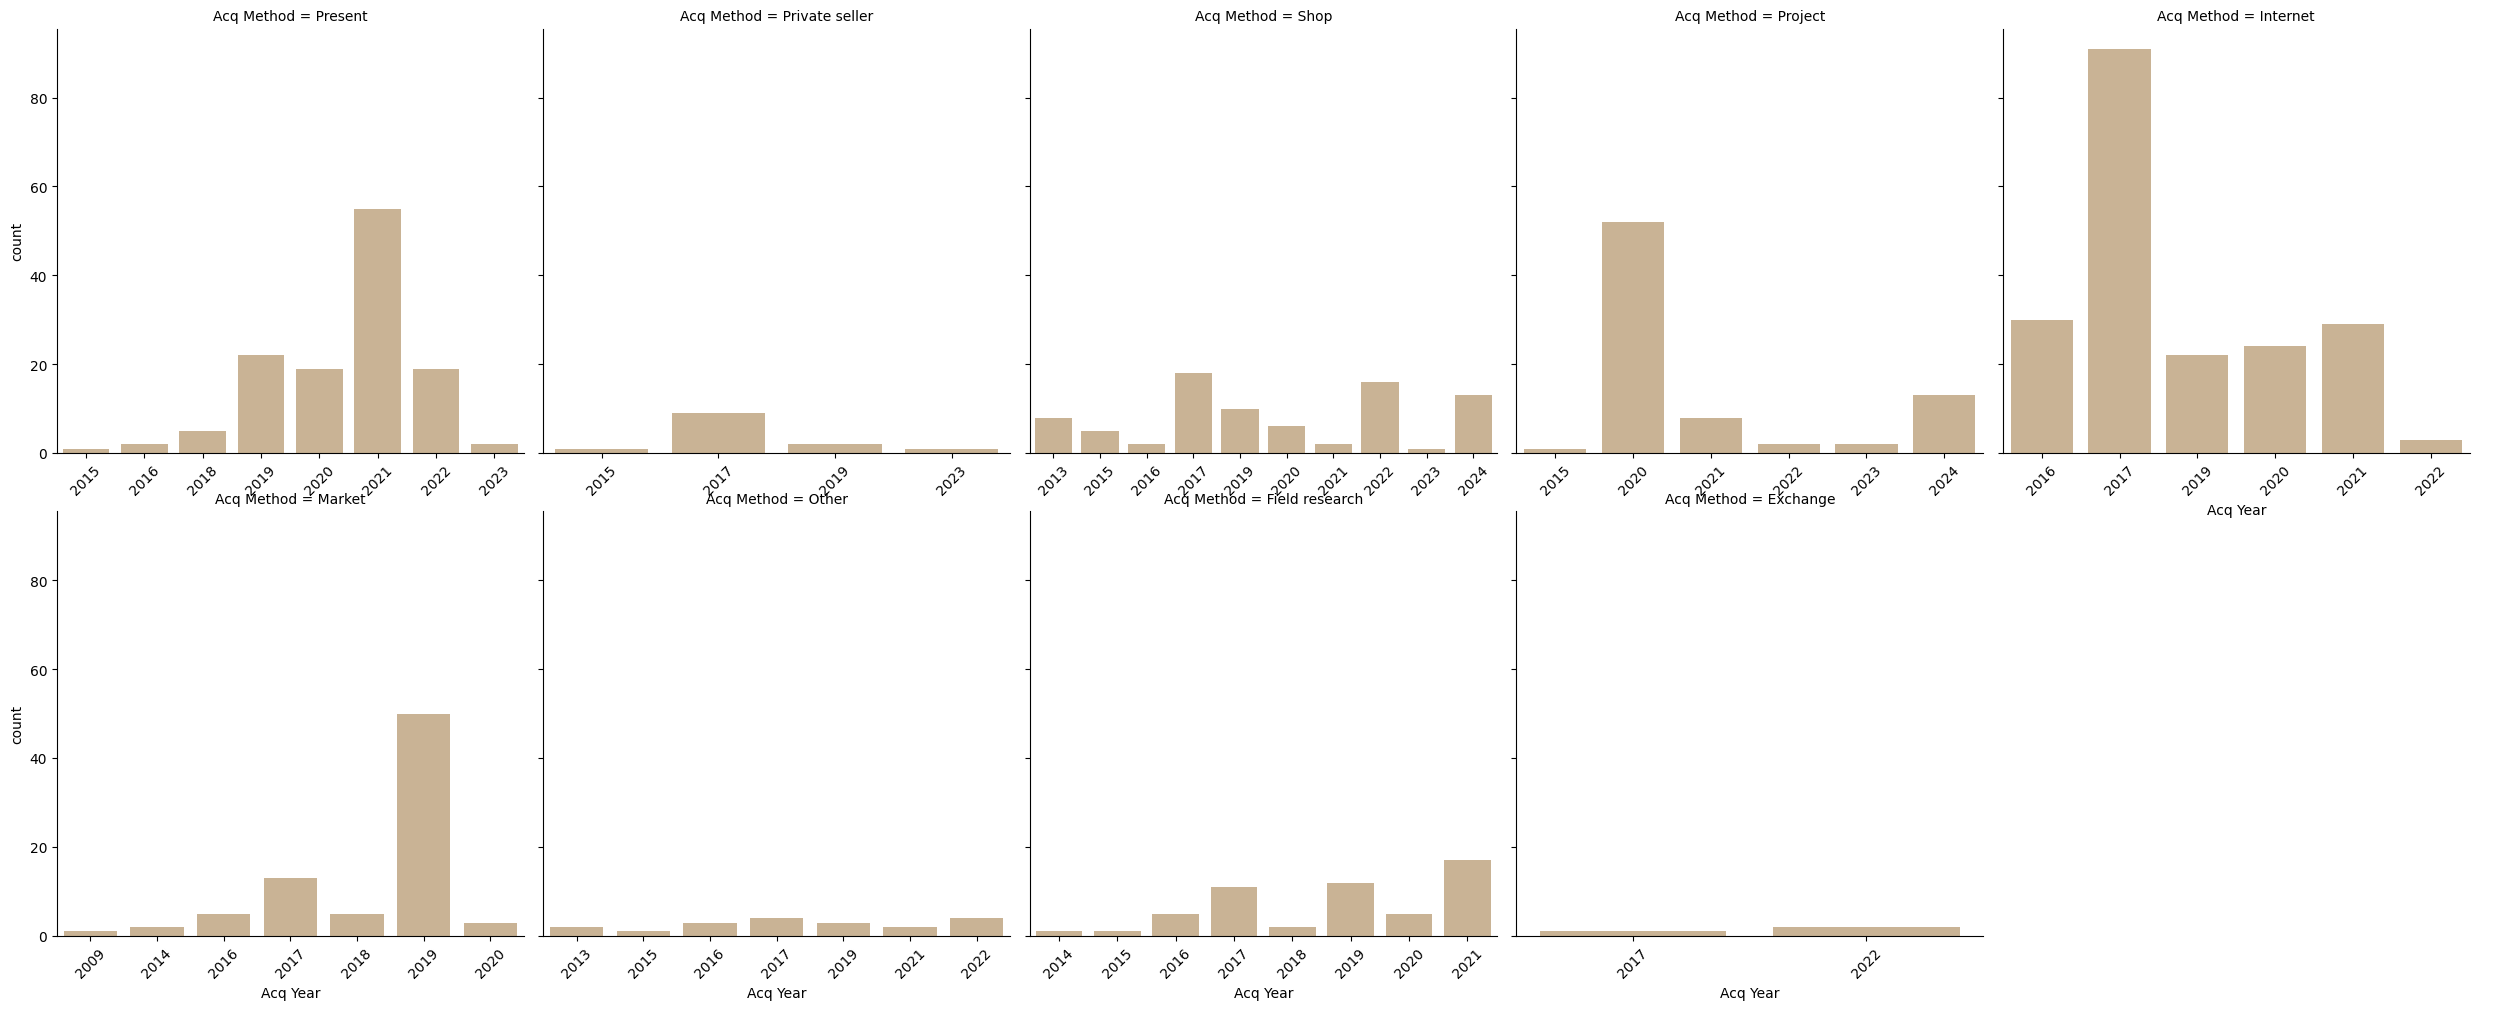

In [ ]:
ax = sns.catplot(x = 'Acq Year', data = df, col = 'Acq Method', kind = "count", col_wrap = 5, color = 'tan', sharex=False)
ax.tick_params(axis='x', labelrotation=45)

**Insights:**

In 2017, a high number of samples were collected by internet channels.

In 2019, a high number of samples were collected by market channels.

In 2020, a high number of samples were collected by project channels.

In 2021, a high number of samples were collected by present channels.

(Everything else is in line with the overall channel distribution.)

In [ ]:
top = df['Country'].value_counts().reset_index().nlargest(20, 'count')
top20 = df[df['Country'].isin(top['Country'])]
top

,Country,count
0,Russia,123
1,Ukraine,76
2,Suriname,48
3,India,36
4,France,30
5,Kyrgyzstan,28
6,Kazakhstan,28
7,China,26
8,Germany,25
9,Nigeria,24


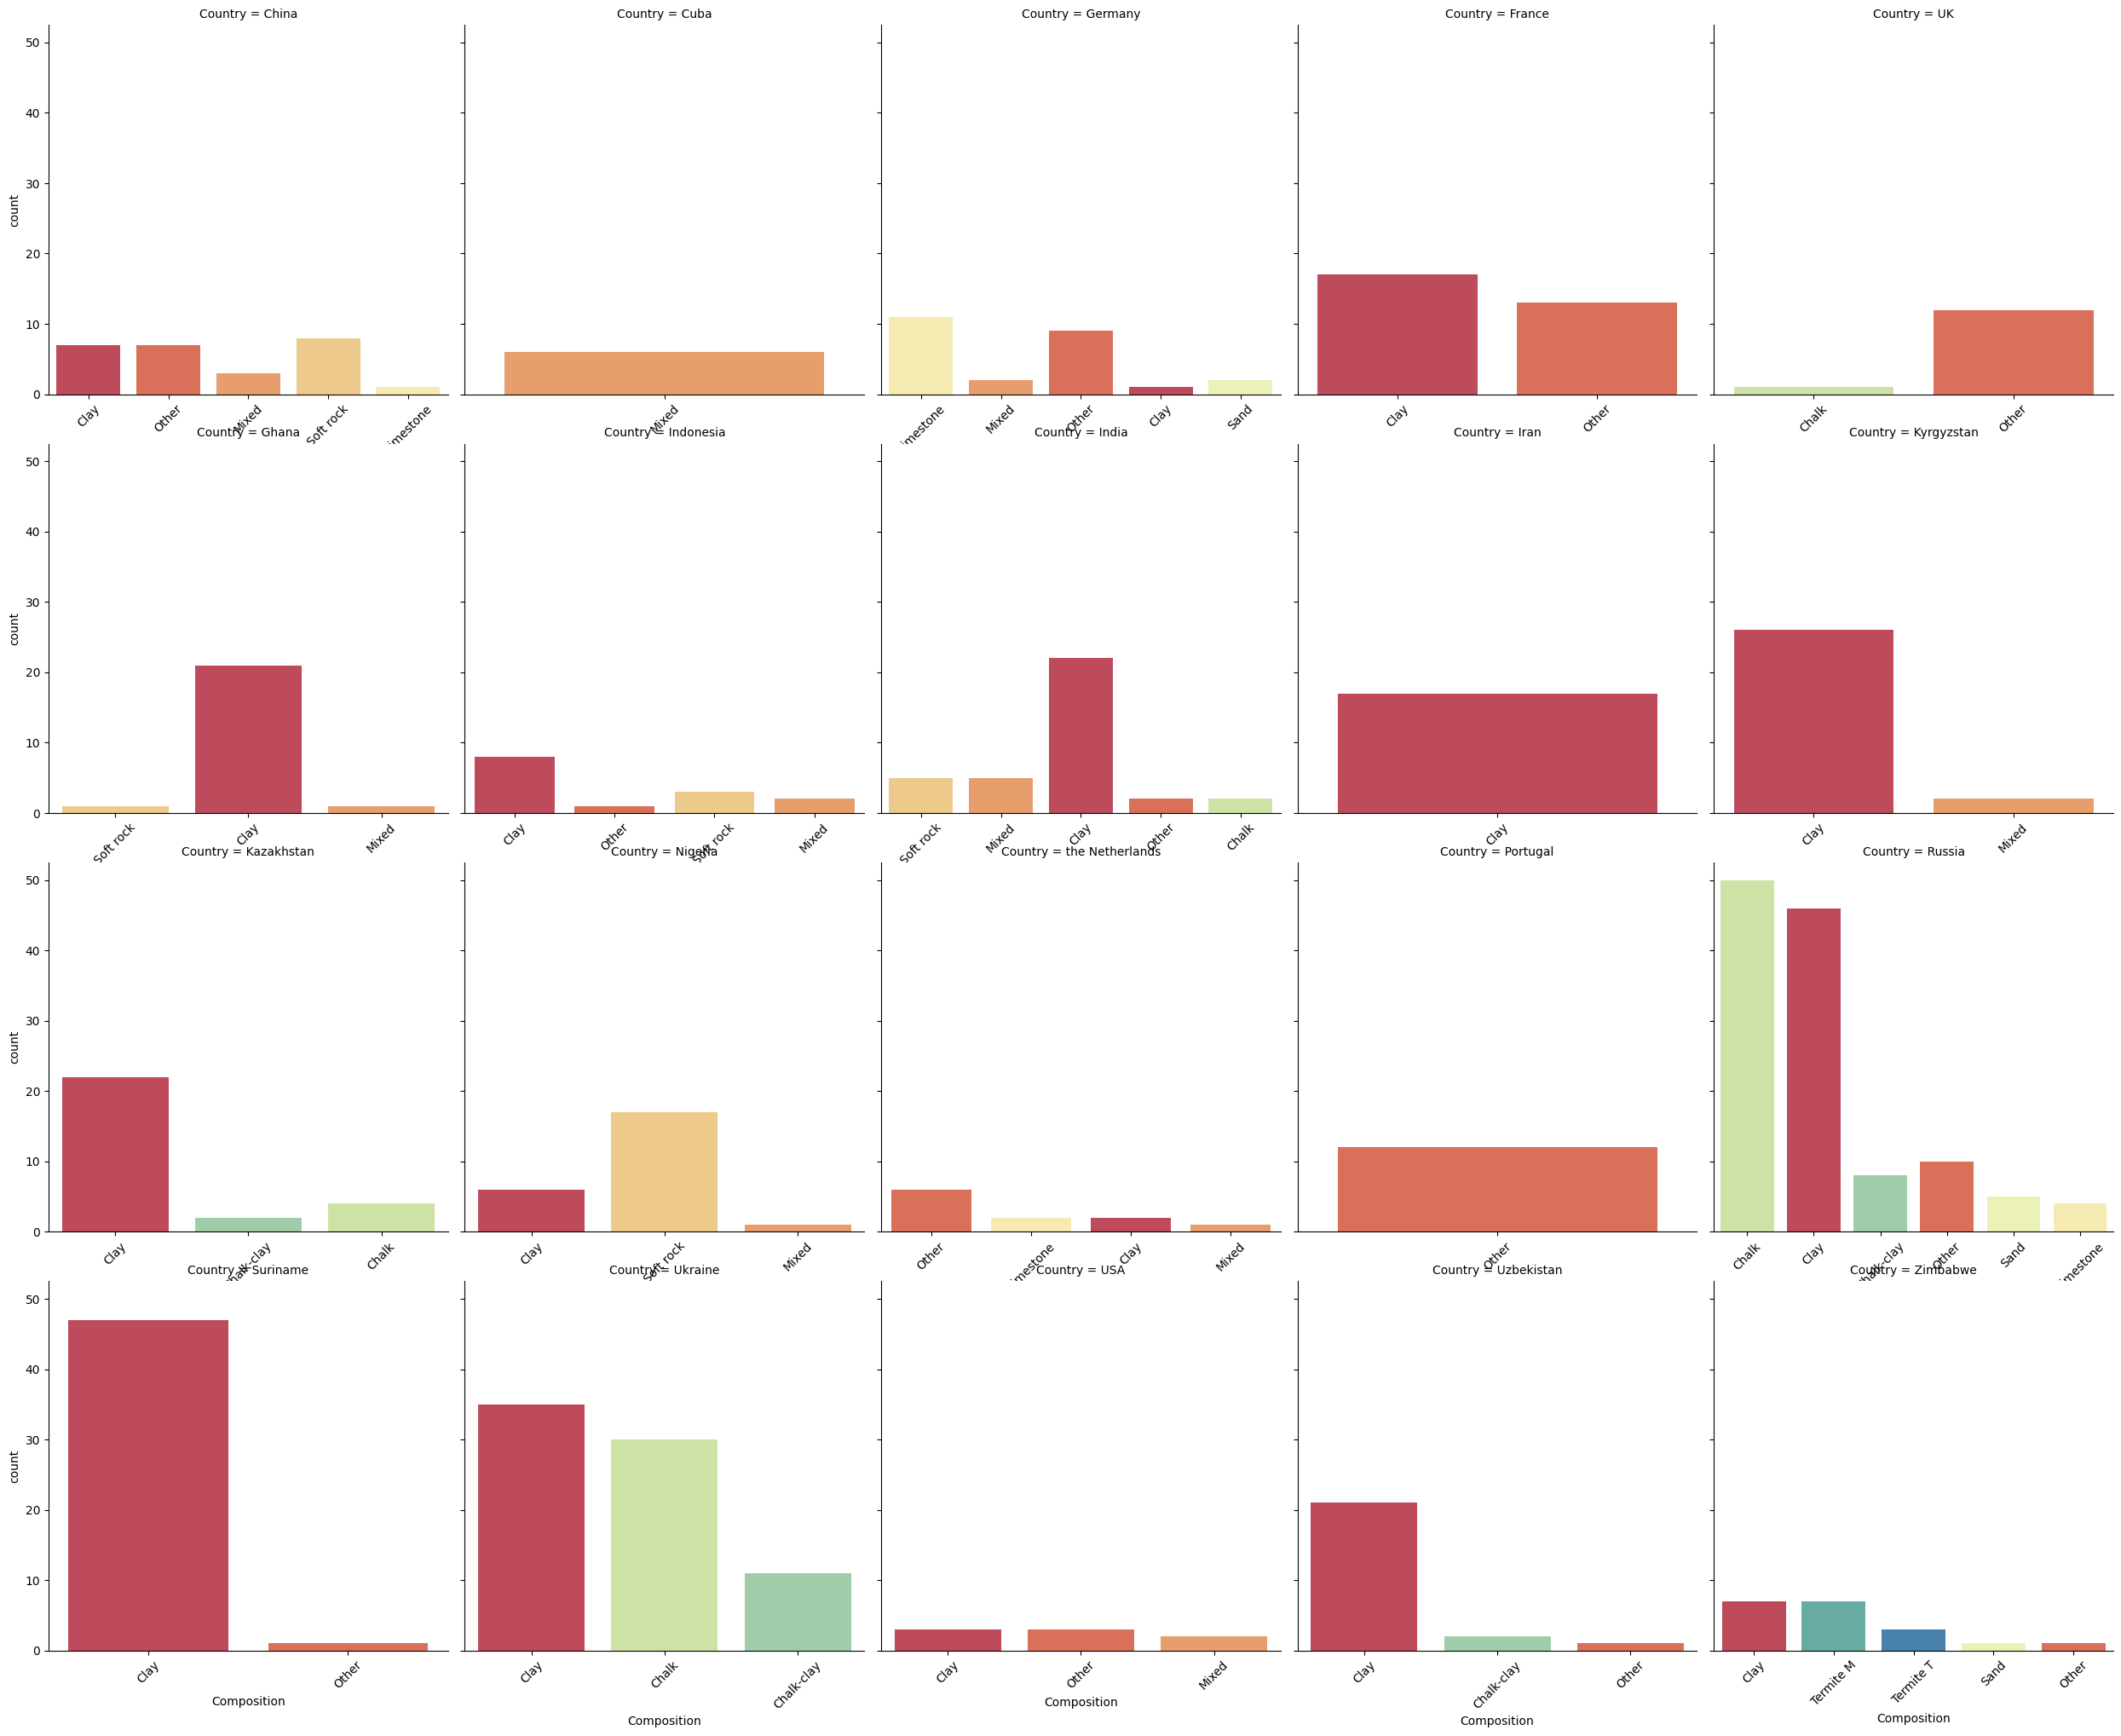

In [ ]:
ax = sns.catplot(x = 'Composition', data = top20, col = 'Country', kind = "count", col_wrap = 5, palette = 'Spectral', hue = 'Composition', sharex=False)
ax.tick_params(axis='x', labelrotation=45)

Insights:

In total, there are 53 countries, but several of these only contributed 1 or 2 minerals to the collection, therefore I have only included the top 20 countires for this analysis, as they contain around 90% of the data.

A lot of of the datasets minerals are from Russia. Not an overwhelming majority, but quite a few. Russia is followed by Ukraine and Suriname.



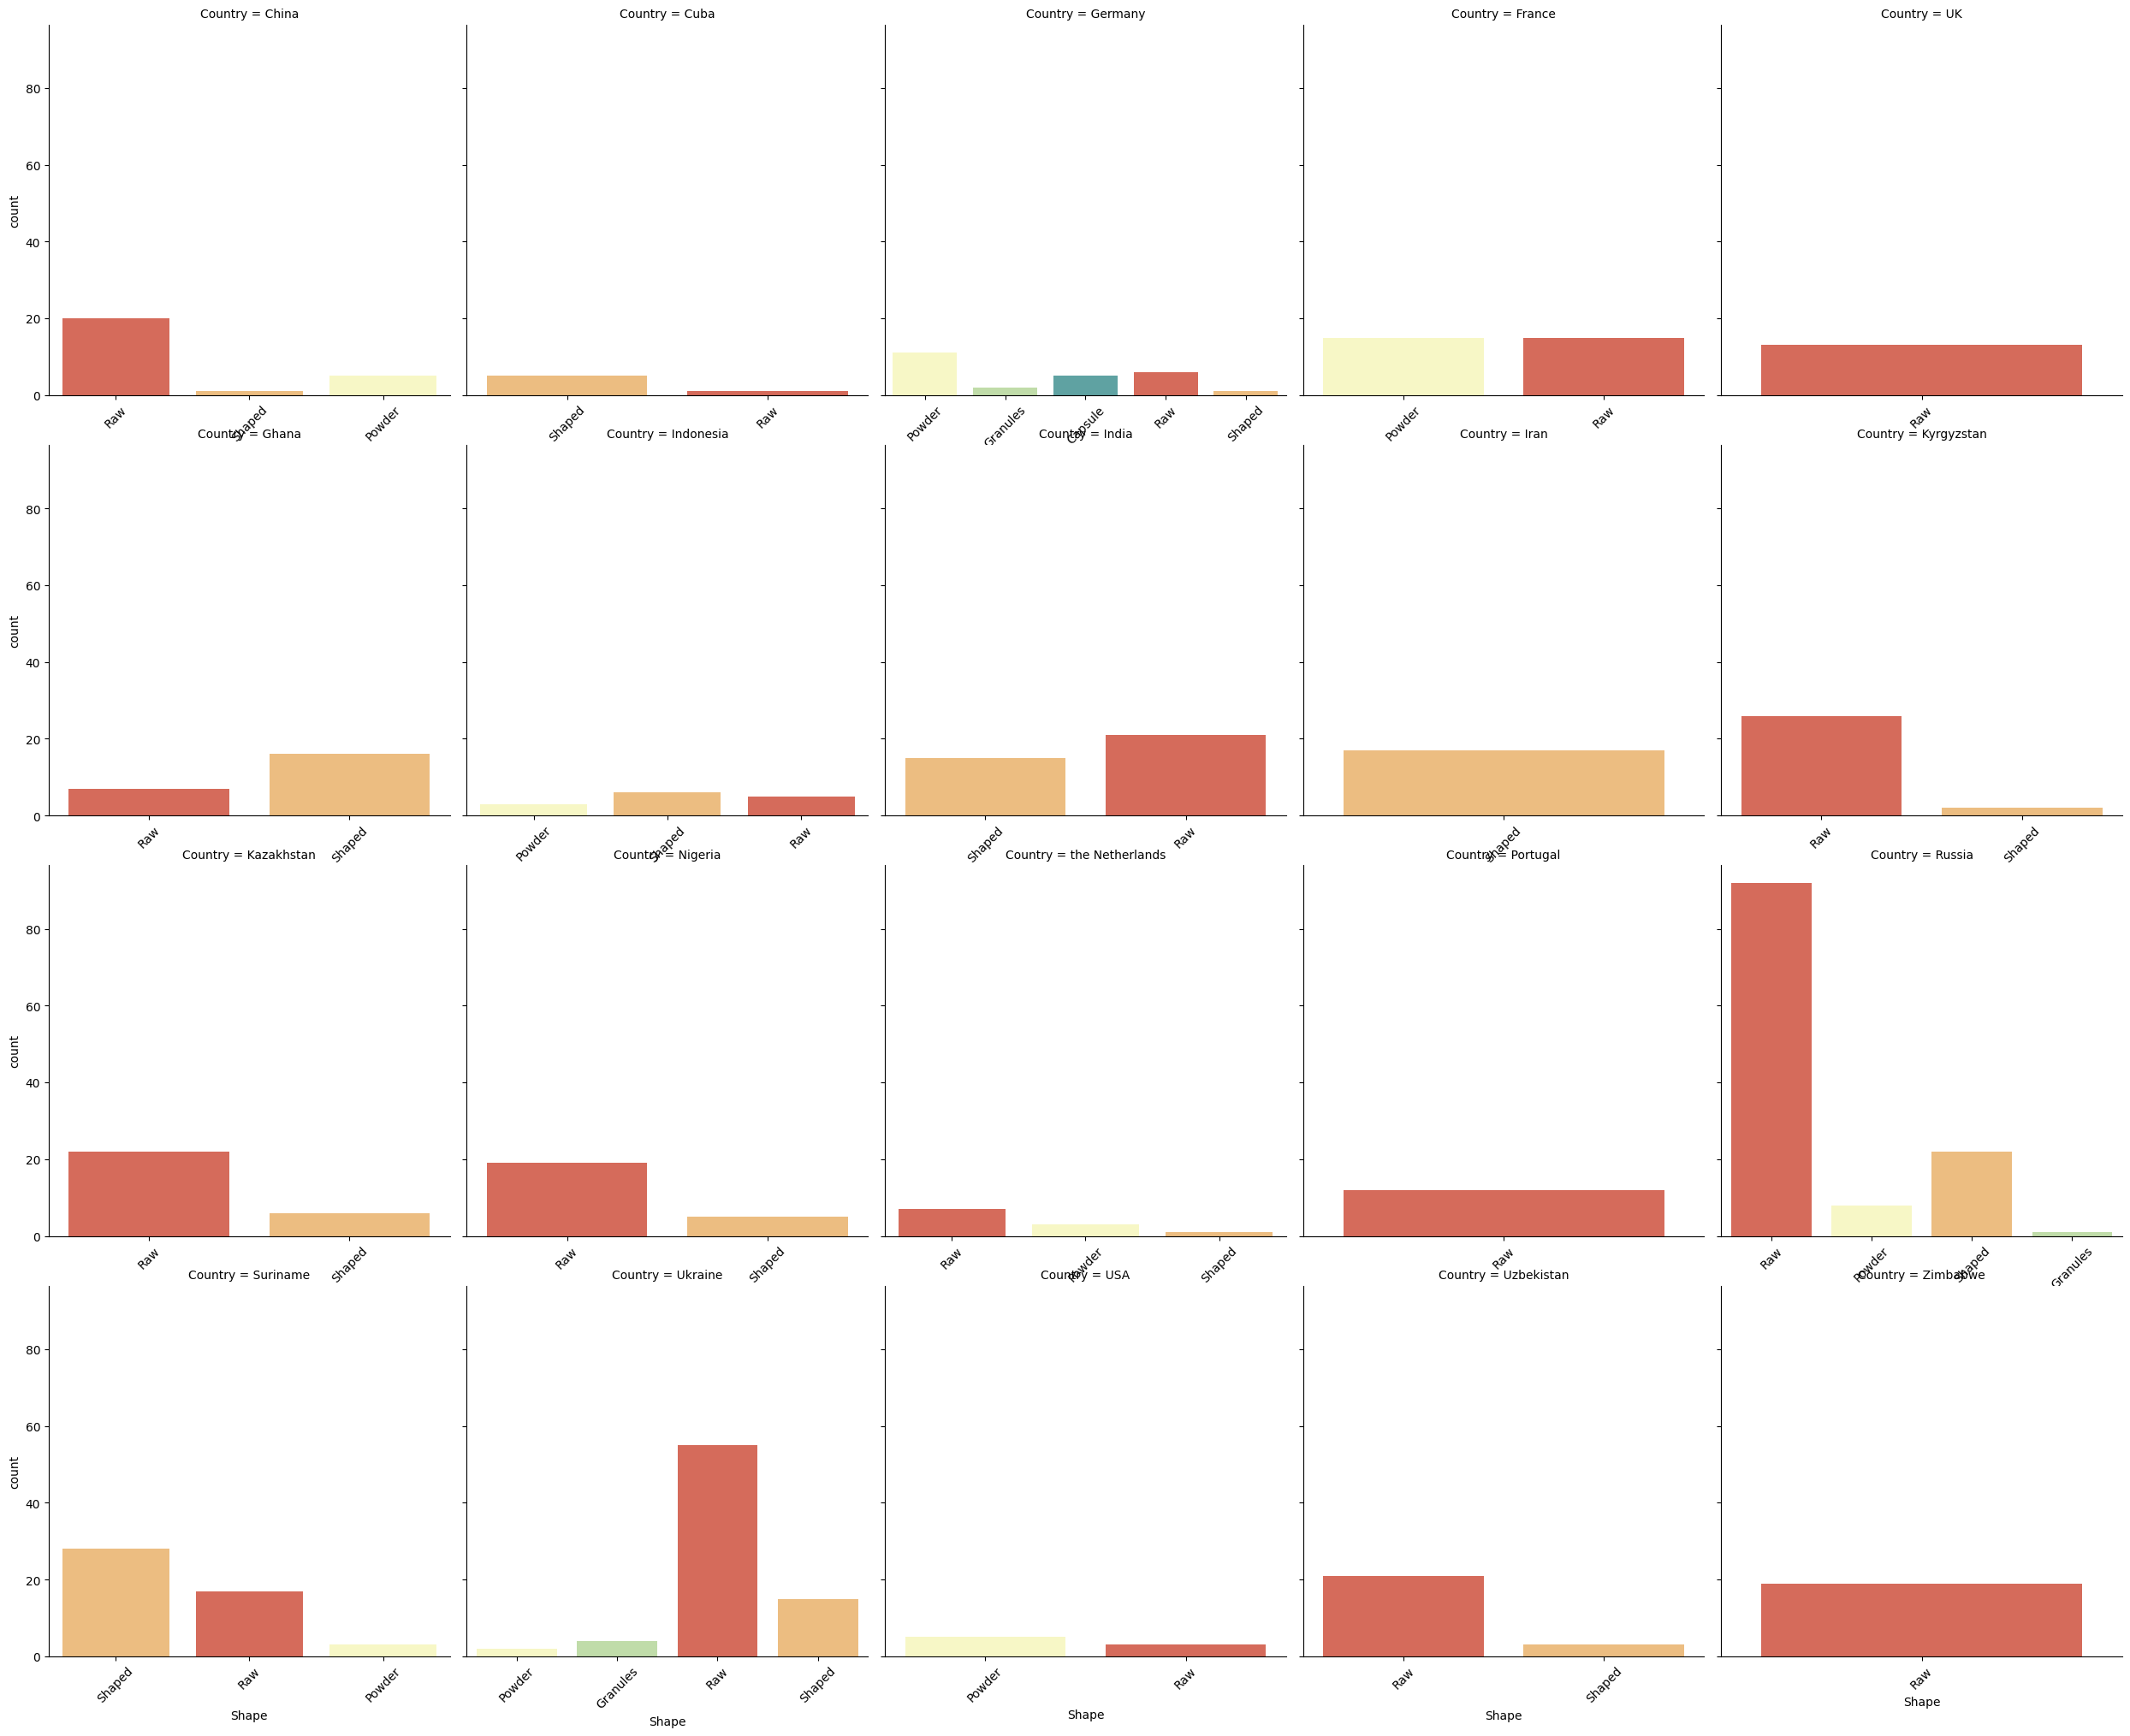

In [ ]:
ax = sns.catplot(x = 'Shape', data = top20, col = 'Country', kind = "count", col_wrap = 5, palette = 'Spectral', hue = 'Shape', sharex=False)
ax.tick_params(axis='x', labelrotation=45)

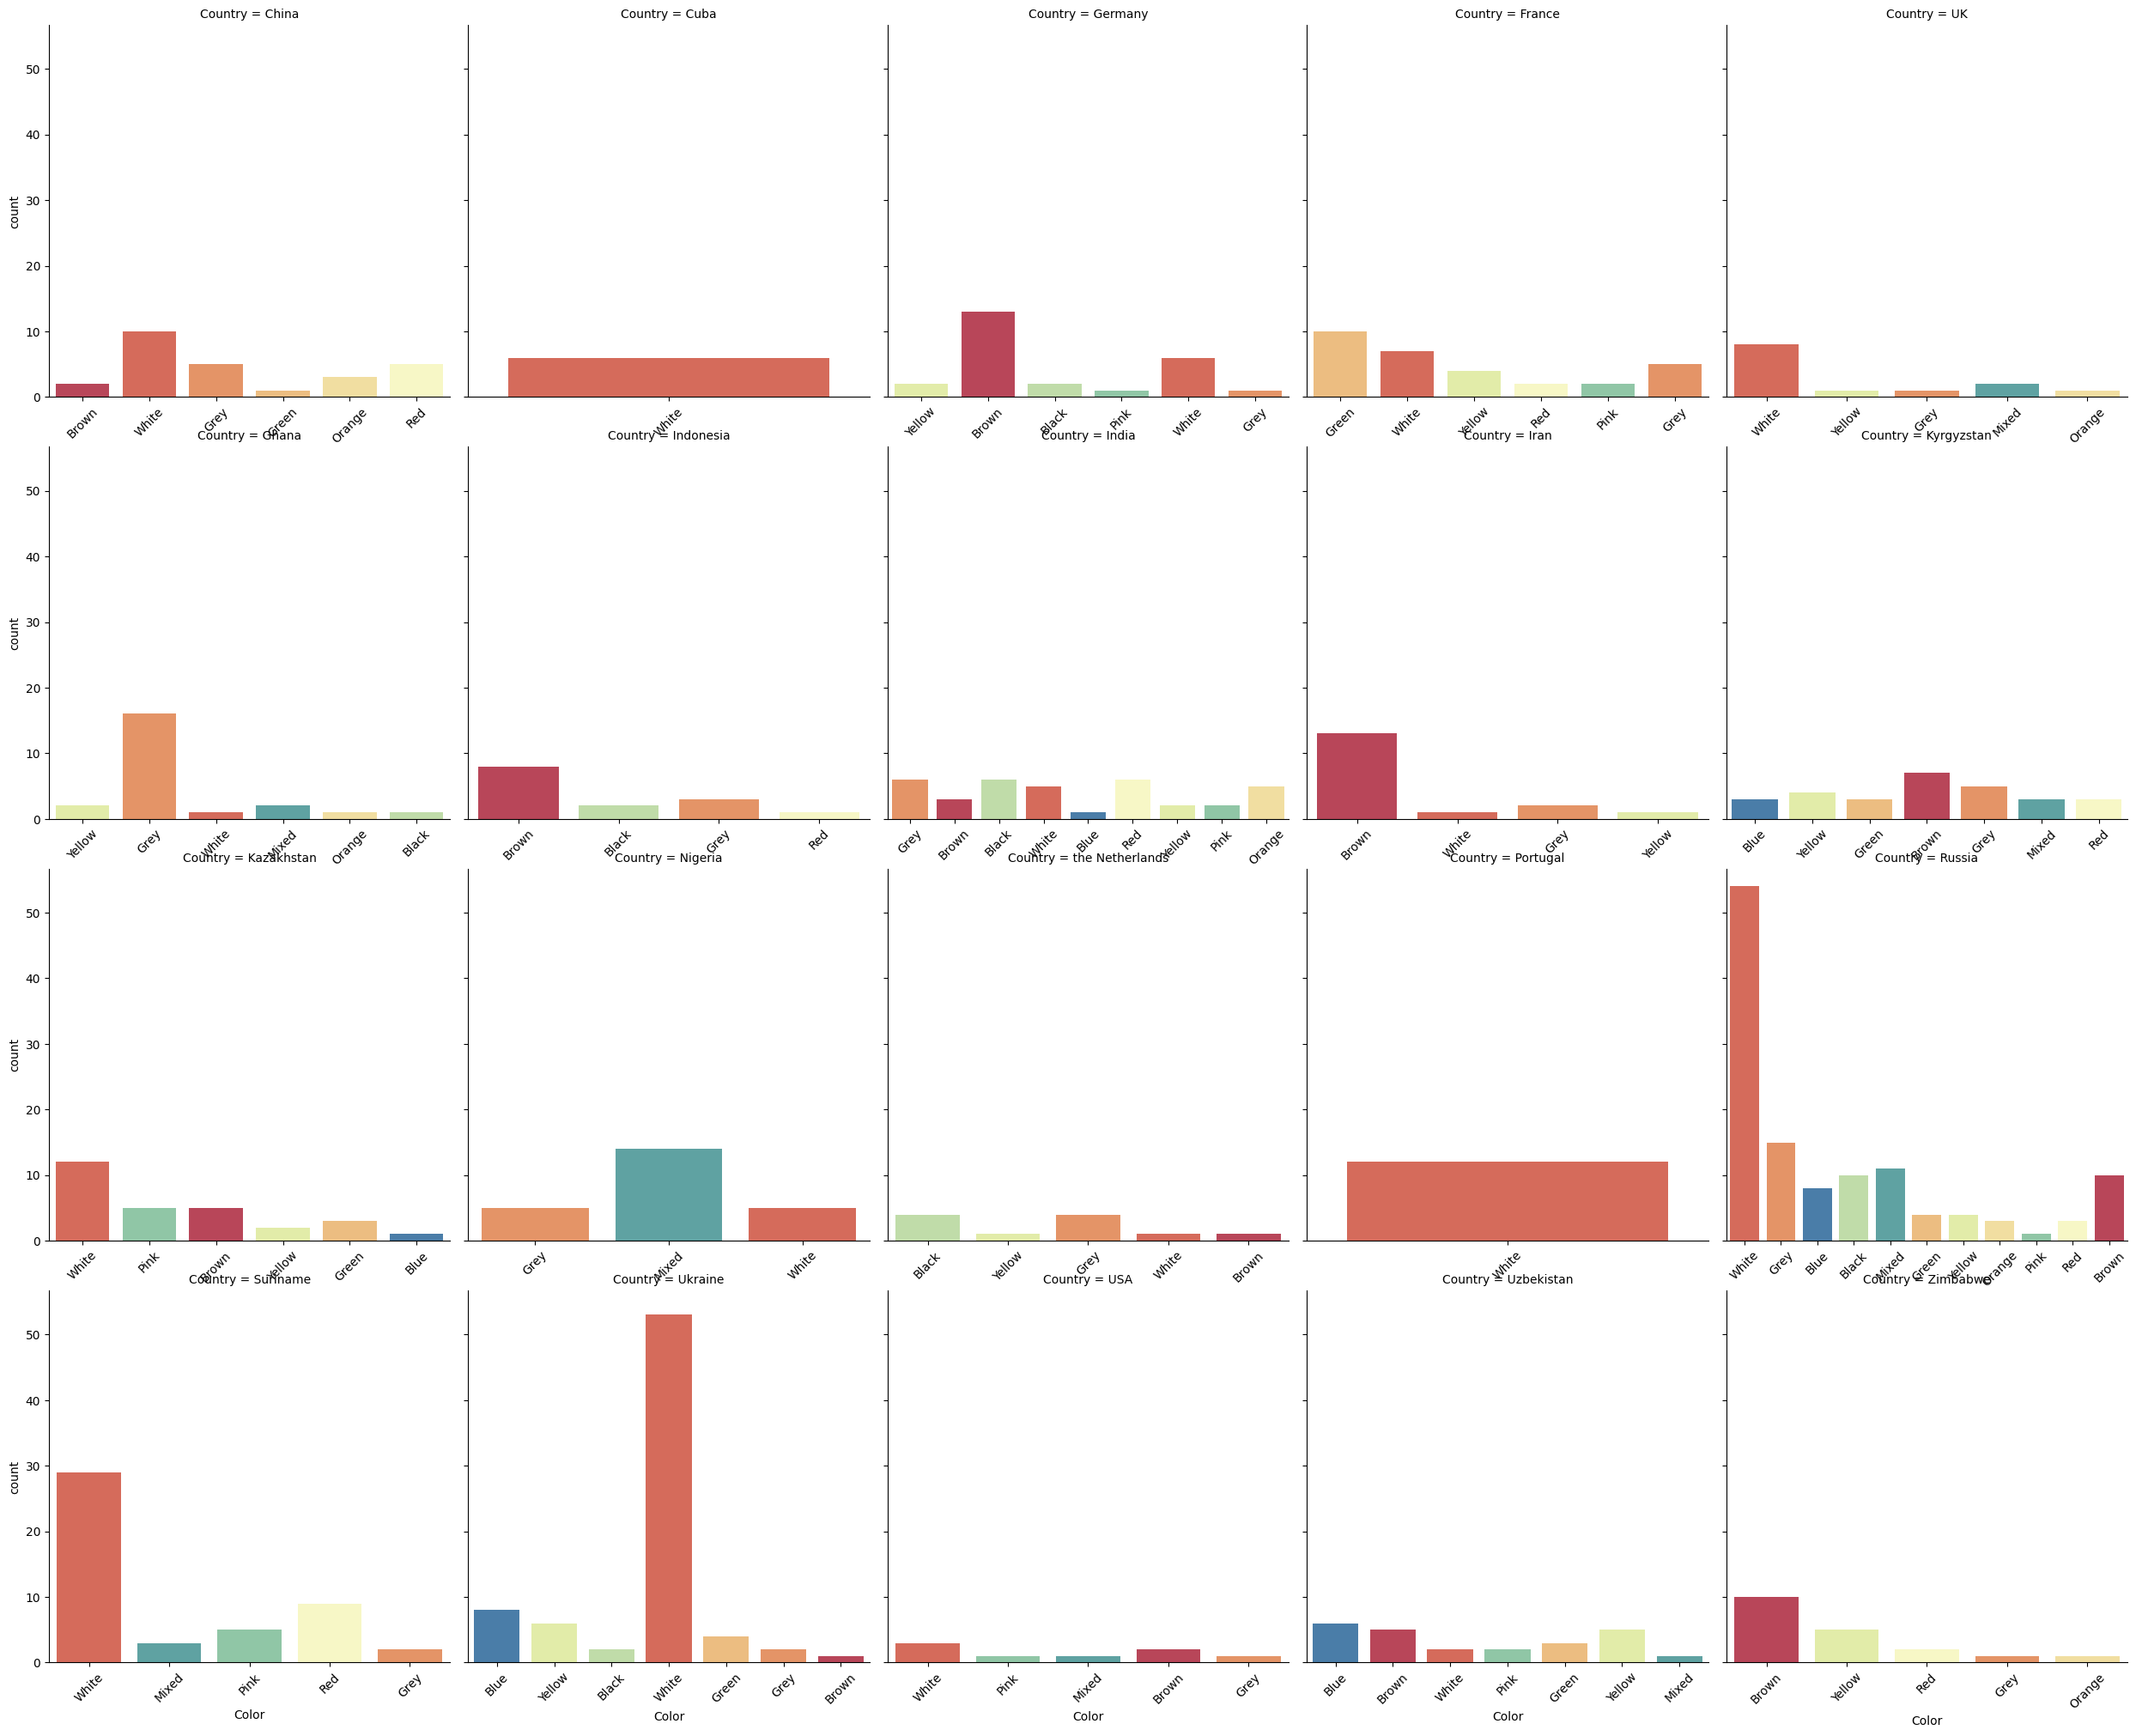

In [ ]:
ax = sns.catplot(x = 'Color', data = top20, col = 'Country', kind = "count", col_wrap = 5, palette = 'Spectral', hue = 'Color', sharex=False)
ax.tick_params(axis='x', labelrotation=45)

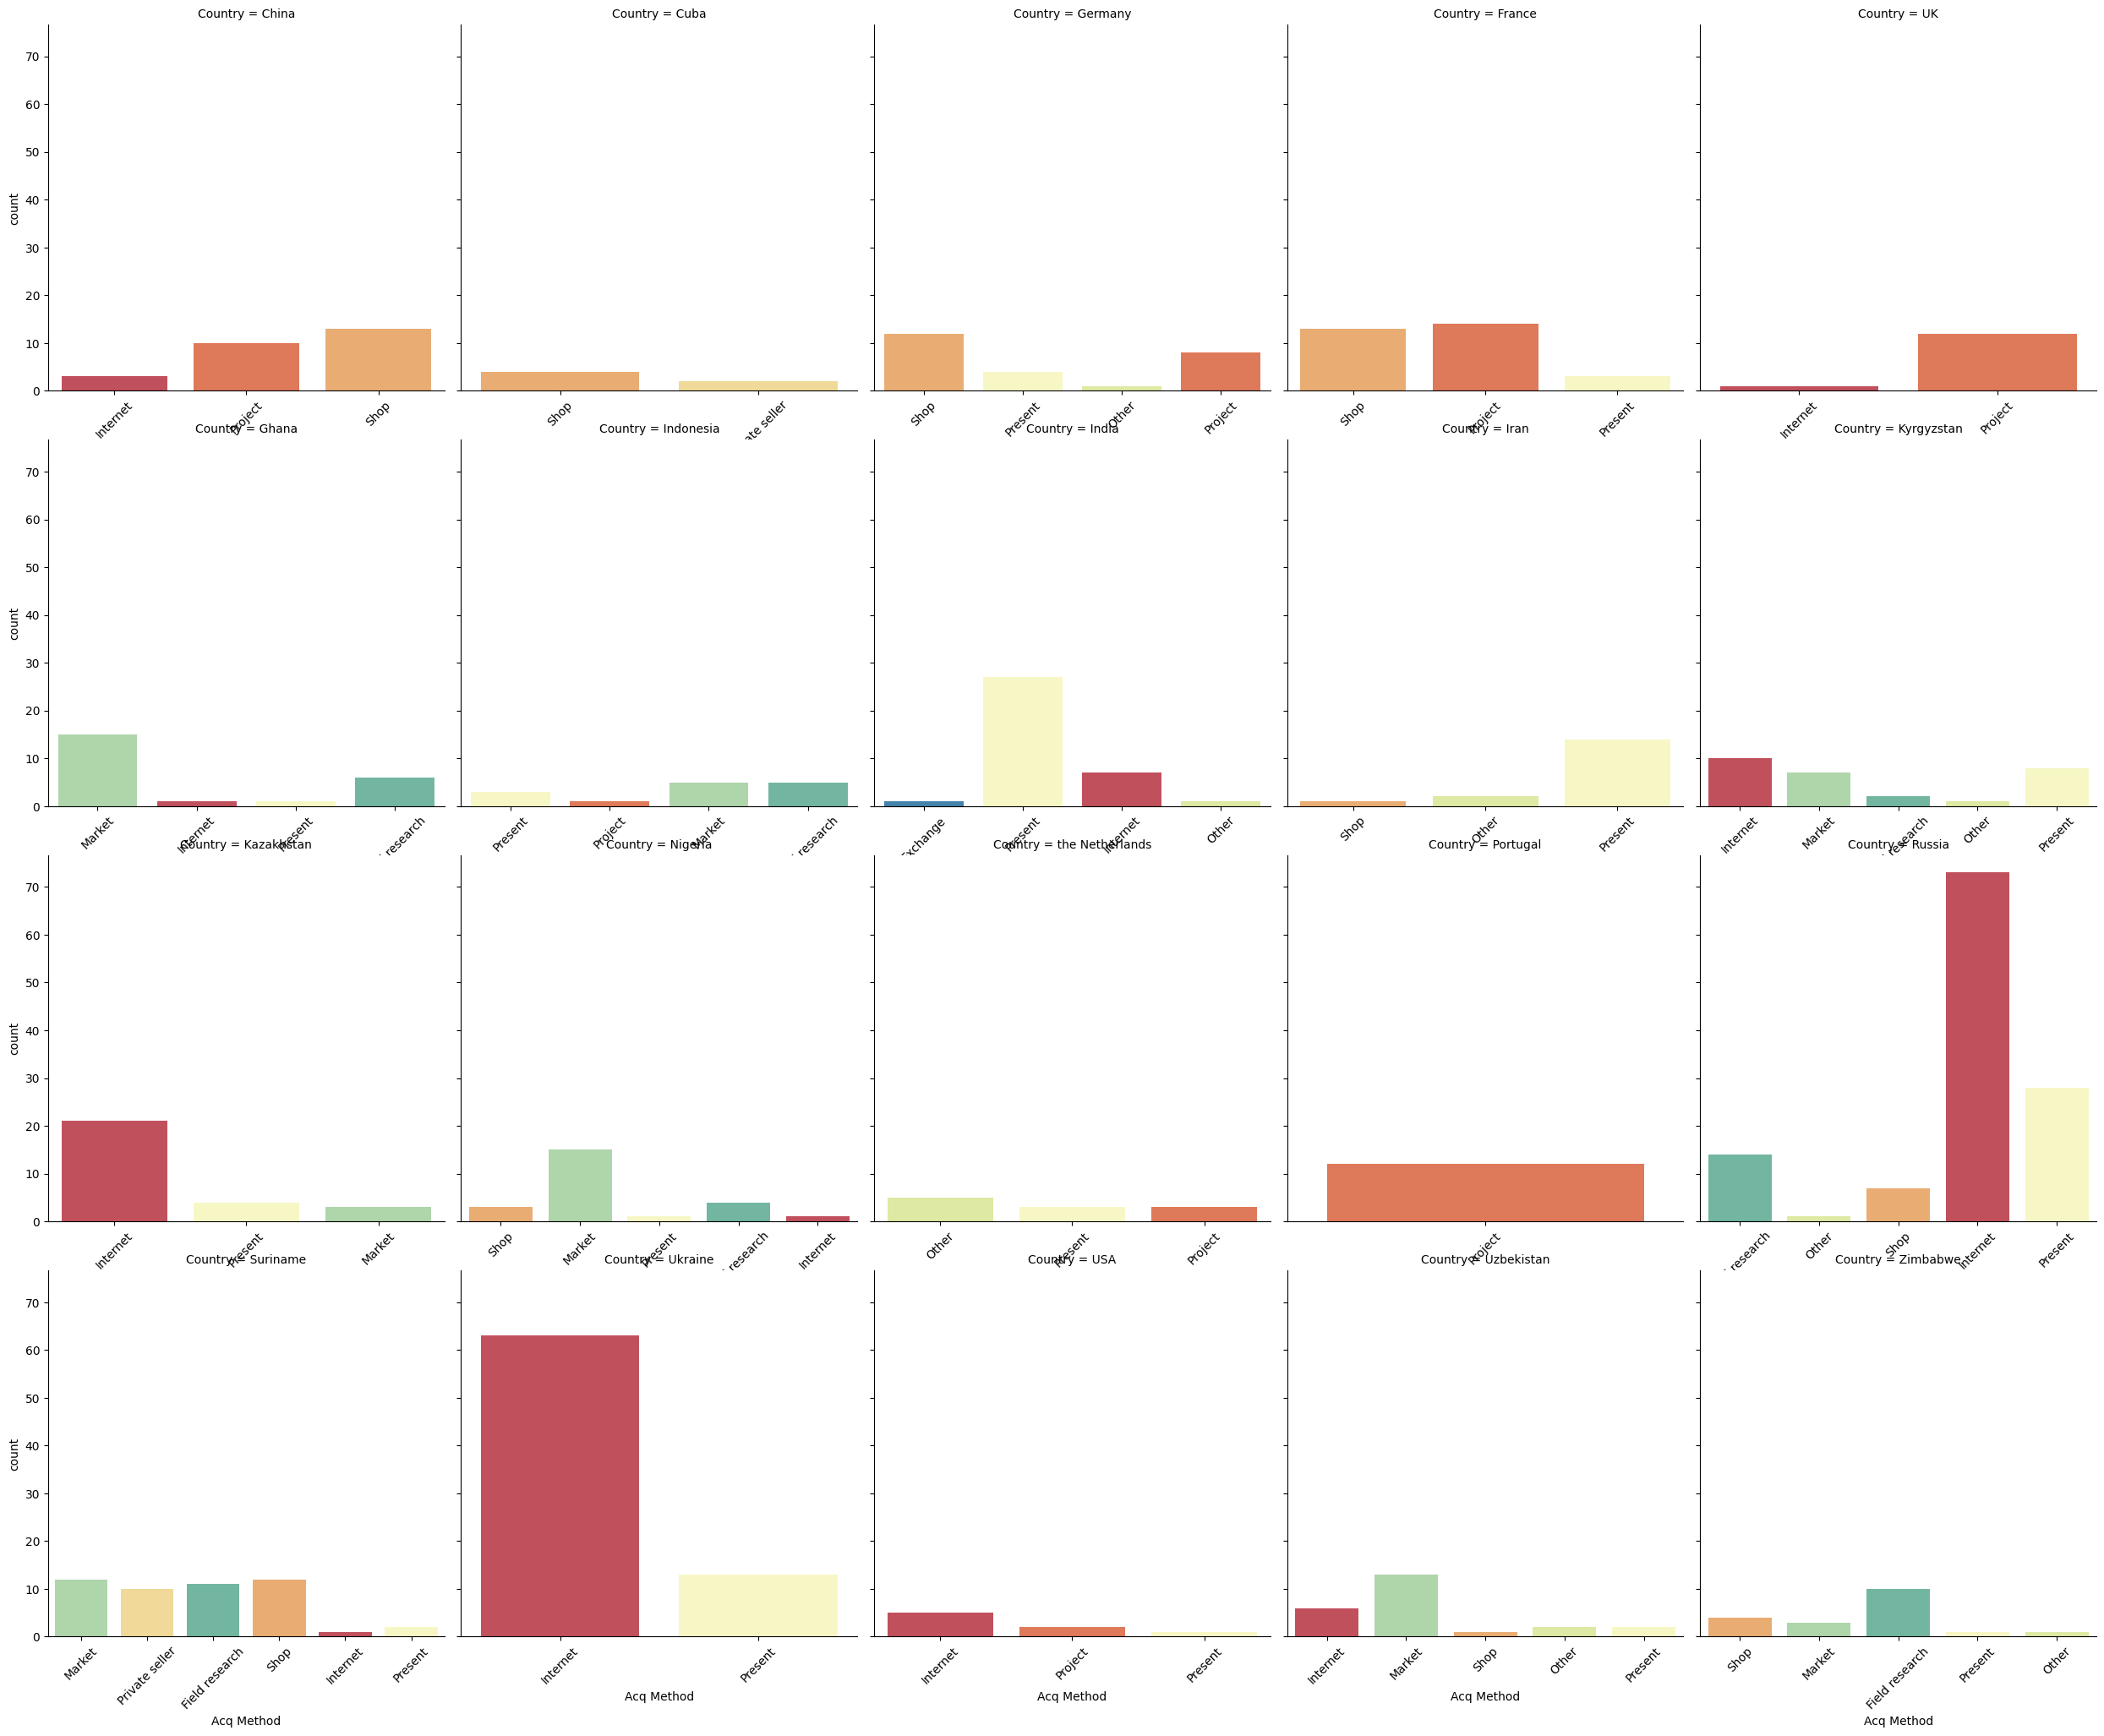

In [ ]:
ax = sns.catplot(x = 'Acq Method', data = top20, col = 'Country', kind = "count", col_wrap = 5, palette = 'Spectral', hue = 'Acq Method', sharex=False)
ax.tick_params(axis='x', labelrotation=45)

In [ ]:
df_exploded1 = df.assign(Taste = df['Taste'].str.split(',')).explode('Taste')
df_exploded1['Taste'] = df_exploded1['Taste'].str.strip()
df_exploded1['Taste'] = df_exploded1['Taste'].replace('N/A', np.nan)

In [ ]:
df_exploded2 = df.assign(Texture = df['Texture'].str.split(',')).explode('Texture')
df_exploded2['Texture'] = df_exploded2['Texture'].str.strip()
df_exploded2['Texture'] = df_exploded2['Texture'].replace('N/A', np.nan)
df_exploded2['Texture'].unique()

array([nan, 'Chalky', 'Creamy', 'Powdery', 'Hard', 'Dry', 'Experience',
       'Soft', 'Sticky', 'Airy', 'Flaky', 'Crunchy', 'Damp', 'Dusty',
       'Crispy', 'Grainy', 'Chewy', 'Dense', 'Smooth', 'Melty', 'Fizzy',
       'Pasty', 'Gooey'], dtype=object)

In [ ]:
taste_counts = df_exploded1['Taste'].value_counts().reset_index()
texture_counts = df_exploded2['Texture'].value_counts().reset_index()

In [ ]:
texture_counts

,Texture,count
0,Soft,144
1,Damp,134
2,Hard,130
3,Creamy,96
4,Crunchy,90
5,Experience,86
6,Dense,80
7,Dry,73
8,Dusty,71
9,Smooth,69


<ipython-input-47-88a5d3e6659e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[0] = sns.barplot(data = taste_counts, x = 'count', y = 'Taste', palette = 'pink', ax = ax[0])
<ipython-input-47-88a5d3e6659e>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[1] = sns.barplot(data = texture_counts, x = 'count', y = 'Texture', palette = 'pink', ax = ax[1])


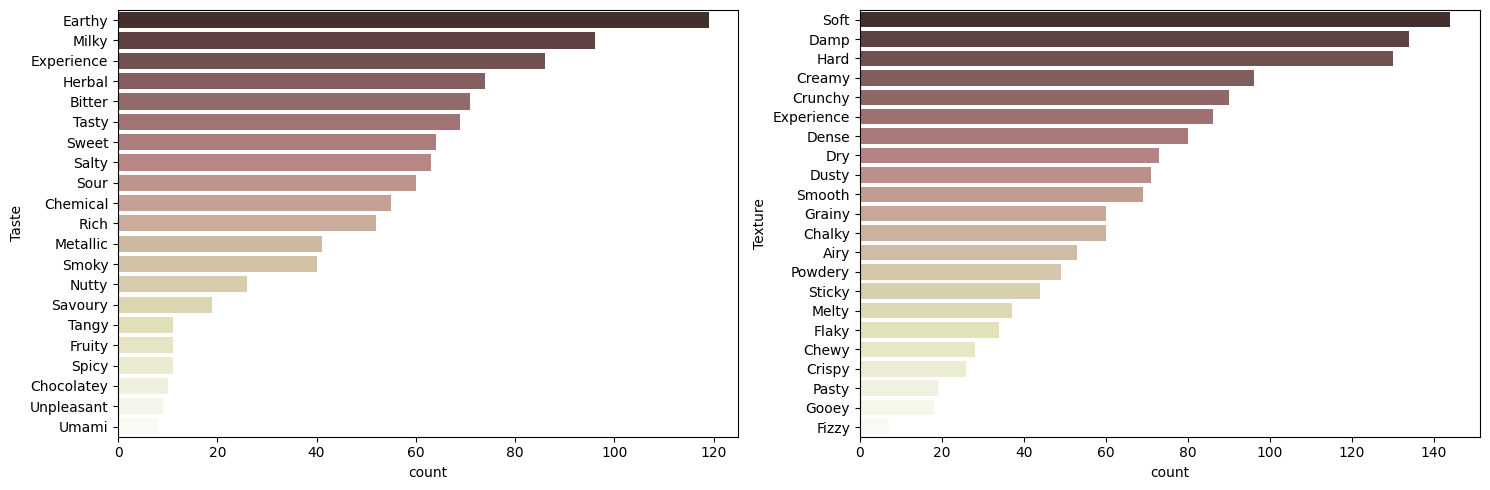

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 5))

ax[0] = sns.barplot(data = taste_counts, x = 'count', y = 'Taste', palette = 'pink', ax = ax[0])

ax[1] = sns.barplot(data = texture_counts, x = 'count', y = 'Texture', palette = 'pink', ax = ax[1])

plt.tight_layout()

In [ ]:
experience = df[df['Taste'].str.contains('exp', na = False)]
ex_exploded = df.assign(
Taste = df['Taste'].str.split(',')).explode('Taste')

In [ ]:
ex_exploded.head()

,index,Name,Country,Composition,Shape,Color,Acq Date,OG_Date,Acq Method,Edibility,Tags,Taste,Texture,Acq Year,Acq Month
0,0,SatinAr Clay,Armenia,Clay,Powder,Brown,2021-09-19,2021-09-19,Present,Eaten,NaN,NaN,NaN,2021,September
1,1,SatinAr Clay,Armenia,Clay,Powder,Brown,2023-08-01,NaN,Private seller,Eaten,NaN,NaN,NaN,2023,NaN
2,2,Schindele's Mineralen,Austria,Clay,Powder,Brown,2022-02-02,2022-02-02,Present,Eaten,"calcium, chemical, creamy, fine, iron, mineral...",Metallic,"Chalky, Creamy, Powdery, Hard, Dry, exp, Soft,...",2022,February
2,2,Schindele's Mineralen,Austria,Clay,Powder,Brown,2022-02-02,2022-02-02,Present,Eaten,"calcium, chemical, creamy, fine, iron, mineral...",Chemical,"Chalky, Creamy, Powdery, Hard, Dry, exp, Soft,...",2022,February
2,2,Schindele's Mineralen,Austria,Clay,Powder,Brown,2022-02-02,2022-02-02,Present,Eaten,"calcium, chemical, creamy, fine, iron, mineral...",Milky,"Chalky, Creamy, Powdery, Hard, Dry, exp, Soft,...",2022,February


**What questions regarding taste and texture do I want to answer?**
1. What are the most common tastes and most common textures? I would like to visualize this with a 2 word clouds and 2 bubble plots (not scatter bubble plots, like, the kind where all the lil bubbles are clustered together.)
2. What are the most common taste and texture combinations? (I would like to do this with a sunburst chart, similar to the one on the website, but I'm not sure how.)
3. I want to make a Tableau visualization that filters taste and texture by mineral name. Like, you punch in or search for a mineral name and it gives you their tastes and textures, as visualized by

In [ ]:
from itertools import product
from collections import Counter

combinations = []

for i, row in df[['Taste', 'Texture']].dropna().iterrows():
    tastes = [t.strip() for t in row['Taste'].split(',')]
    textures = [x.strip() for x in row['Texture'].split(',')]
    row_combos = product(tastes, textures)
    combinations.extend(row_combos)

combo_counts = Counter(combinations)

combo_df = pd.DataFrame(combo_counts.items(), columns = ['Pair', 'Count'])
combo_df[['Taste', 'Texture']] = pd.DataFrame(combo_df['Pair'].tolist(), index = combo_df.index)
combo_df.drop(columns='Pair', inplace=True)

combo_df = combo_df.sort_values(by='Count', ascending = False).reset_index(drop = True)

In [ ]:
combo_df.head()

NameError: name 'combo_df' is not defined

In [ ]:
combo_df

,Count,Taste,Texture
0,111,Earthy,Damp
1,91,Milky,Creamy
2,86,Experience,Experience
3,76,Herbal,Damp
4,75,Earthy,Soft
...,...,...,...
453,1,Chocolatey,Sticky
454,1,Nutty,Gooey
455,1,Tangy,Gooey
456,1,Chocolatey,Melty
